In [50]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [51]:
img_size = 224
batch_size = 32

In [52]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [53]:
train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.


Found 50 images belonging to 2 classes.


In [54]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(1,activation='sigmoid'))

In [55]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [57]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5911 - loss: 1.4889 - val_accuracy: 0.6600 - val_loss: 0.5763
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.7389 - loss: 0.5295 - val_accuracy: 0.7400 - val_loss: 0.5495
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.7980 - loss: 0.4567 - val_accuracy: 0.7400 - val_loss: 0.5196
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 556ms/step - accuracy: 0.8325 - loss: 0.4216 - val_accuracy: 0.7400 - val_loss: 0.5224
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.8571 - loss: 0.3565 - val_accuracy: 0.8000 - val_loss: 0.4787
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 500ms/step - accuracy: 0.8966 - loss: 0.3001 - val_accuracy: 0.7800 - val_loss: 0.4396
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 474ms/step - accuracy: 0.9163 - loss: 0.2195 - val_accuracy: 0.8400 - val_loss: 0.4596
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 521ms/step - accuracy: 0.9458 - loss: 0.1395 - val_accuracy: 0.8800 - val_loss: 0.421

In [58]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8800 - loss: 0.5716
Validation Accuracy: 0.8799999952316284


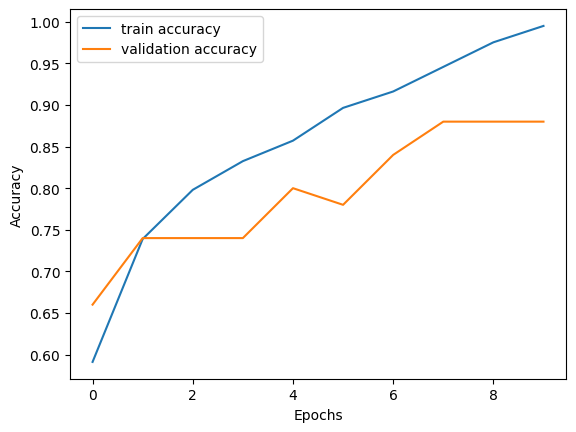

In [59]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()